# StudentLife — EDA, Cleaning & Preprocessing

**Dataset**: Dartmouth StudentLife Study
**Role in EmoCare**: Behavioral/temporal proxy signals + PHQ-9 ground truth outcome

## 0. Imports & Paths

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pyreadr

PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DIR       = os.path.join(PROJECT_ROOT, 'data', 'raw', 'studentlife')
EMA_DIR       = os.path.join(RAW_DIR, 'EMA')
SURVEY_DIR    = os.path.join(RAW_DIR, 'survey')
INTERIM_DIR   = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(INTERIM_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Project root: D:\EmoCare


## 1. Load PHQ-9 Survey & EMA Signals

In [2]:
def load_rds(path):
    res = pyreadr.read_r(path)
    return res[list(res.keys())[0]]

df_phq9 = load_rds(os.path.join(SURVEY_DIR, 'PHQ-9.Rds'))
item_map = {'Not at all': 0, 'Several days': 1, 'More than half the days': 2, 'Nearly every day': 3}
q_cols = [f'Q{i}' for i in range(1, 10)]
for q in q_cols:
    if q in df_phq9.columns:
        df_phq9[f'{q}_num'] = df_phq9[q].map(item_map)
df_phq9['phq9_score'] = df_phq9[[f'{q}_num' for q in q_cols if f'{q}_num' in df_phq9.columns]].sum(axis=1)
print('Parsed PHQ-9 survey records:', len(df_phq9))
df_phq9[['uid', 'type', 'phq9_score']].head()

Parsed PHQ-9 survey records: 84


,uid,type,phq9_score
0,0,pre,2
1,1,pre,5
2,2,pre,13
3,3,pre,2
4,4,pre,6


## 2. EDA — PHQ-9 Score Distribution

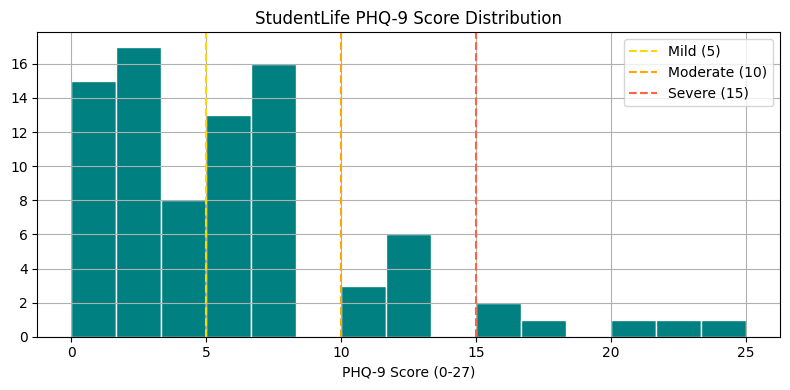

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
df_phq9['phq9_score'].hist(bins=15, ax=ax, color='teal', edgecolor='white')
for cutoff, label, col in [(5, 'Mild', 'gold'), (10, 'Moderate', 'orange'), (15, 'Severe', 'tomato')]:
    ax.axvline(cutoff, linestyle='--', color=col, label=f'{label} ({cutoff})')
ax.set_title('StudentLife PHQ-9 Score Distribution')
ax.set_xlabel('PHQ-9 Score (0-27)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'studentlife_phq9_dist.png'), dpi=150)
plt.show()

## 3. Behavioral Features & Risk Tier Grounding

In [4]:
feat_path = os.path.join(PROCESSED_DIR, 'studentlife_behavioral_features.csv')
df_final = pd.read_csv(feat_path)
print('Loaded processed StudentLife features:', len(df_final), 'students | Shape:', df_final.shape)
print('Risk Tier Grounding Breakdown:')
print(df_final['risk_tier'].value_counts())
df_final.head()

Loaded processed StudentLife features: 38 students | Shape: (38, 55)
Risk Tier Grounding Breakdown:
risk_tier
Low         31
High         4
Moderate     3
Name: count, dtype: int64


,uid,mood_happy_mean,mood_happy_std,mood_timestamp_mean,mood_timestamp_std,mood_sad_mean,mood_sad_std,mood_1_timestamp_mean,mood_1_timestamp_std,mood_1_tomorrow_mean,...,exercise_walk_mean,exercise_walk_std,behavior_timestamp_mean,behavior_timestamp_std,pam_timestamp_mean,pam_timestamp_std,phq9_score,risk_tier,risk_label,split
0,15,1.708333,0.500000,1.368342e+09,8.921716e+05,1.000000,0.242536,1.367994e+09,1.062907e+06,1.772370,...,1.800000,0.447214,1.365677e+09,9.818664e+05,1.366666e+09,1.603506e+06,1.0,Low,0.0,train
1,5,1.708333,0.500000,1.368342e+09,8.921716e+05,1.000000,0.242536,1.367994e+09,1.062907e+06,1.772370,...,2.324301,0.687552,1.364501e+09,9.147624e+05,1.366885e+09,1.591587e+06,0.0,Low,0.0,train
2,58,2.117647,1.268974,1.368515e+09,9.522005e+05,1.058824,0.242536,1.368765e+09,1.213915e+06,2.066667,...,2.866667,1.332183,1.366911e+09,1.388738e+06,1.366545e+09,1.572276e+06,8.0,Low,0.0,train
3,9,1.708333,0.500000,1.368342e+09,8.921716e+05,1.000000,0.242536,1.367994e+09,1.062907e+06,1.772370,...,2.324301,0.687552,1.364479e+09,3.962697e+04,1.366872e+09,1.509808e+06,2.0,Low,0.0,train
4,27,1.000000,0.000000,1.368091e+09,1.061543e+06,1.000000,0.000000,1.367405e+09,3.024755e+05,2.000000,...,1.454545,0.687552,1.365317e+09,8.040994e+05,1.366545e+09,1.572276e+06,7.0,Low,0.0,train
